In [1]:
import os
import cv2
import numpy as np
import shutil
from pathlib import Path
from tqdm import tqdm

# Source and destination paths (relative to current notebook location)
source_dataset = "animal_dataset"
dest_dataset = "animal_dataset_with_noice"

# Create destination folders
os.makedirs(f"{dest_dataset}/images/train", exist_ok=True)
os.makedirs(f"{dest_dataset}/images/val", exist_ok=True)
os.makedirs(f"{dest_dataset}/images/test", exist_ok=True)
os.makedirs(f"{dest_dataset}/labels/train", exist_ok=True)
os.makedirs(f"{dest_dataset}/labels/val", exist_ok=True)
os.makedirs(f"{dest_dataset}/labels/test", exist_ok=True)

print("✓ Created destination folders")
print(f"✓ Source: {source_dataset}")
print(f"✓ Destination: {dest_dataset}")

✓ Created destination folders
✓ Source: animal_dataset
✓ Destination: animal_dataset_with_noice


In [2]:
def add_gaussian_noise(image, mean=0, std=25):
    """Add Gaussian noise to image"""
    noise = np.random.normal(mean, std, image.shape).astype(np.uint8)
    noisy_image = cv2.add(image, noise)
    return noisy_image

def add_salt_pepper_noise(image, salt_prob=0.01, pepper_prob=0.01):
    """Add salt and pepper noise to image"""
    noisy_image = image.copy()
    salt_mask = np.random.random(image.shape[:2]) < salt_prob
    noisy_image[salt_mask] = 255
    pepper_mask = np.random.random(image.shape[:2]) < pepper_prob
    noisy_image[pepper_mask] = 0
    return noisy_image

def add_blur(image, kernel_size=15):
    """Add Gaussian blur to image"""
    return cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)

def add_motion_blur(image, kernel_size=45):
    """Add motion blur to image"""
    kernel = np.zeros((kernel_size, kernel_size))
    kernel[int((kernel_size-1)/2), :] = np.ones(kernel_size)
    kernel = kernel / kernel_size
    return cv2.filter2D(image, -1, kernel)

def night_bw(image, gamma=1.8, alpha=1.2, beta=-20):
    """Convert to night-time B&W with low-light effect"""
    table = np.array([((i / 255.0) ** gamma) * 255 for i in np.arange(256)]).astype("uint8")
    dark = cv2.LUT(image, table)
    adjusted = cv2.convertScaleAbs(dark, alpha=alpha, beta=beta)
    gray = cv2.cvtColor(adjusted, cv2.COLOR_BGR2GRAY)
    bw = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    return bw

def augment_image(image):
    """Apply multiple augmentation types"""
    augmented_images = []
    augmented_images.append(("original", image))
    augmented_images.append(("gaussian_noise", add_gaussian_noise(image, std=25)))
    augmented_images.append(("gaussian_blur", add_blur(image, kernel_size=15)))
    augmented_images.append(("motion_blur", add_motion_blur(image, kernel_size=45)))
    augmented_images.append(("night_bw", night_bw(image)))
    return augmented_images

print("✓ Augmentation functions defined")

✓ Augmentation functions defined


In [3]:
import random

def process_dataset(split, augment_percentage=1.0):
    """Process train, val, or test split with augmentation"""
    print(f"\n{'='*60}")
    print(f"Processing {split.upper()} split")
    print(f"{'='*60}")
    
    image_dir = f"{source_dataset}/images/{split}"
    label_dir = f"{source_dataset}/labels/{split}"
    
    dest_image_dir = f"{dest_dataset}/images/{split}"
    dest_label_dir = f"{dest_dataset}/labels/{split}"
    
    image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    print(f"Found {len(image_files)} images")
    print(f"Will augment ALL images (100%)")
    
    stats = {
        'original': 0,
        'gaussian_noise': 0,
        'gaussian_blur': 0,
        'motion_blur': 0,
        'night_bw': 0
    }
    
    for image_file in tqdm(image_files, desc=f"Processing {split}"):
        image_path = os.path.join(image_dir, image_file)
        image = cv2.imread(image_path)
        
        if image is None:
            print(f"Warning: Could not read {image_file}")
            continue
        
        label_file = os.path.splitext(image_file)[0] + '.txt'
        label_path = os.path.join(label_dir, label_file)
        
        if not os.path.exists(label_path):
            print(f"Warning: Label not found for {image_file}")
            continue
        
        # Apply all augmentations to every image
        augmented_images = augment_image(image)
        
        for aug_type, aug_image in augmented_images:
            base_name = os.path.splitext(image_file)[0]
            ext = os.path.splitext(image_file)[1]
            new_image_file = f"{base_name}_{aug_type}{ext}"
            new_label_file = f"{base_name}_{aug_type}.txt"
            
            cv2.imwrite(os.path.join(dest_image_dir, new_image_file), aug_image)
            shutil.copy2(label_path, os.path.join(dest_label_dir, new_label_file))
            
            stats[aug_type] += 1
    
    print(f"\n{split.upper()} Statistics:")
    for aug_type in ['original', 'gaussian_noise', 'gaussian_blur', 'motion_blur', 'night_bw']:
        print(f"  {aug_type}: {stats[aug_type]} images")
    print(f"  Total: {sum(stats.values())} images")
    
    return stats

print("✓ Processing function defined (100% augmentation for ALL images)")

✓ Processing function defined (100% augmentation for ALL images)


In [4]:
# Process all splits
all_stats = {}

for split in ['train', 'val', 'test']:
    try:
        stats = process_dataset(split)
        all_stats[split] = stats
    except Exception as e:
        print(f"Error processing {split}: {e}")

# Print overall summary
print(f"\n{'='*60}")
print("OVERALL SUMMARY")
print(f"{'='*60}")
for split, stats in all_stats.items():
    print(f"\n{split.upper()}: {sum(stats.values())} total images")
    
total_images = sum(sum(stats.values()) for stats in all_stats.values())
print(f"\n✓ Dataset augmentation complete!")
print(f"✓ Total augmented images: {total_images}")


Processing TRAIN split
Found 3204 images
Will augment ALL images (100%)


Processing train:   0%|          | 0/3204 [00:00<?, ?it/s]

Processing train: 100%|██████████| 3204/3204 [17:24<00:00,  3.07it/s]



TRAIN Statistics:
  original: 3204 images
  gaussian_noise: 3204 images
  gaussian_blur: 3204 images
  motion_blur: 3204 images
  night_bw: 3204 images
  Total: 16020 images

Processing VAL split
Found 948 images
Will augment ALL images (100%)


Processing val: 100%|██████████| 948/948 [04:48<00:00,  3.29it/s]



VAL Statistics:
  original: 948 images
  gaussian_noise: 948 images
  gaussian_blur: 948 images
  motion_blur: 948 images
  night_bw: 948 images
  Total: 4740 images

Processing TEST split
Found 425 images
Will augment ALL images (100%)


Processing test: 100%|██████████| 425/425 [01:34<00:00,  4.52it/s]


TEST Statistics:
  original: 425 images
  gaussian_noise: 425 images
  gaussian_blur: 425 images
  motion_blur: 425 images
  night_bw: 425 images
  Total: 2125 images

OVERALL SUMMARY

TRAIN: 16020 total images

VAL: 4740 total images

TEST: 2125 total images

✓ Dataset augmentation complete!
✓ Total augmented images: 22885


Visualizing sample augmentations...


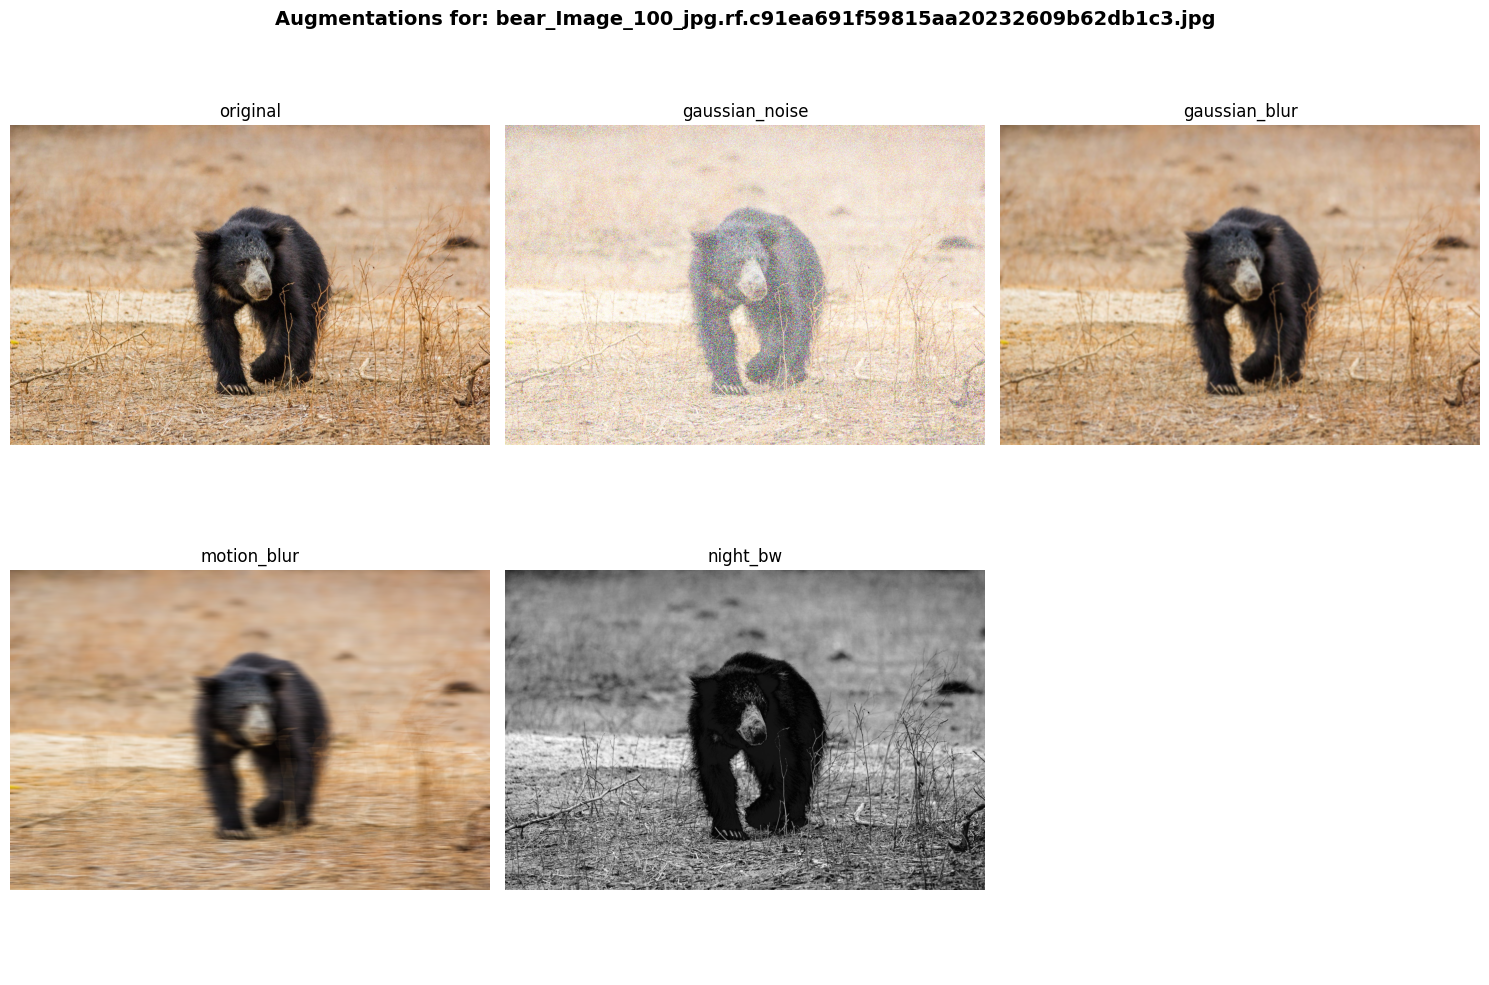

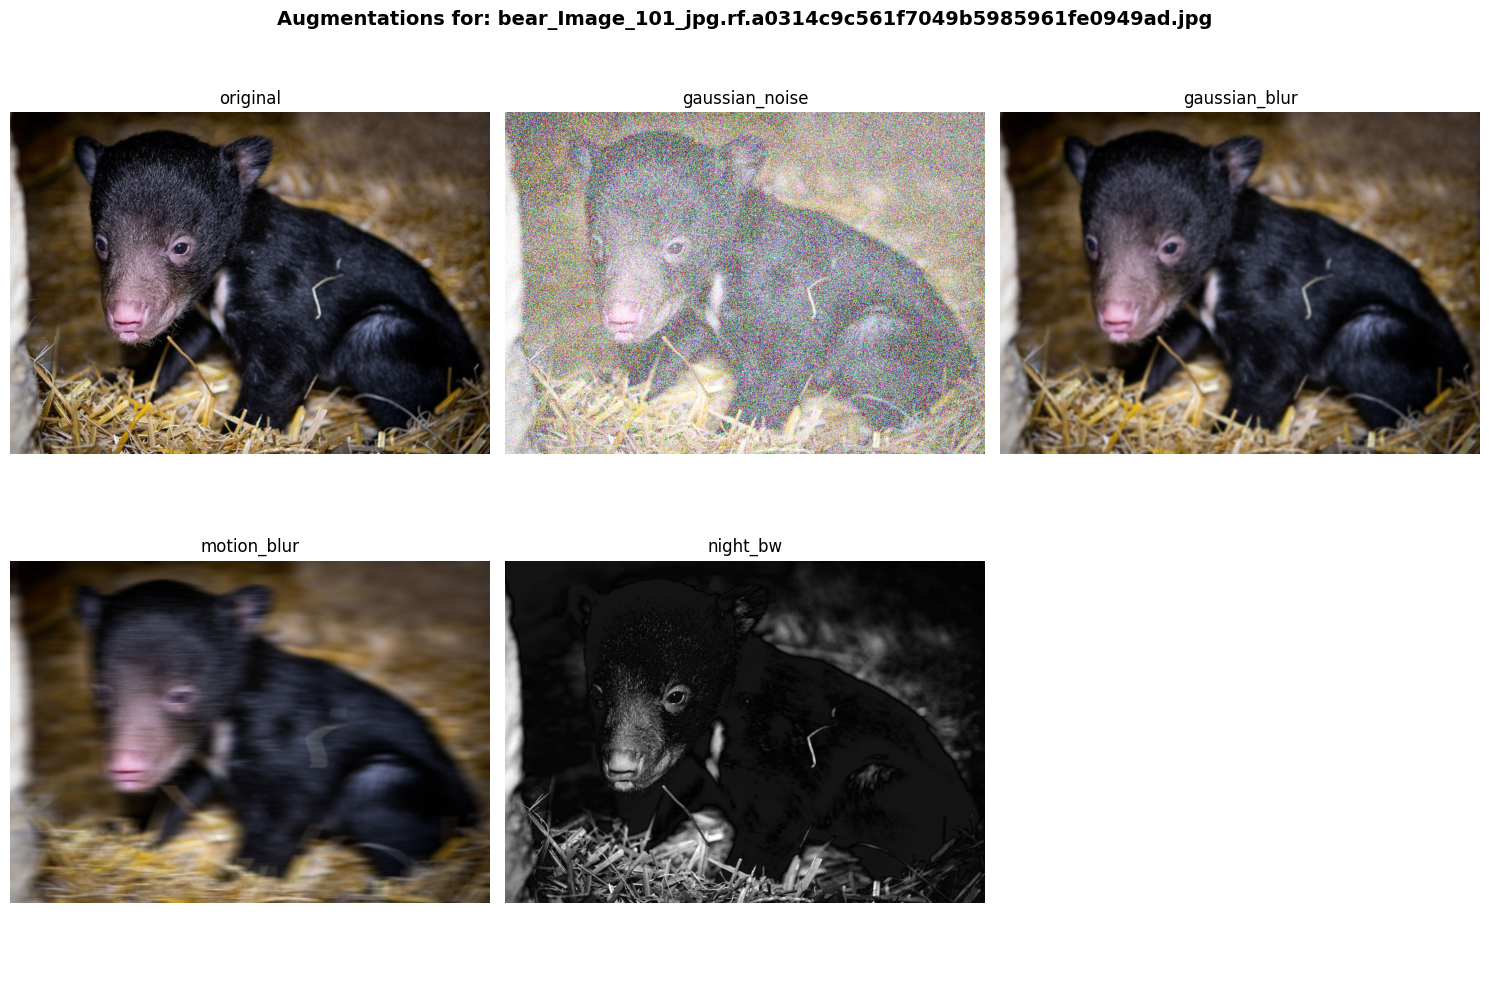

In [5]:
# Visualize some augmented images
import matplotlib.pyplot as plt

def visualize_augmentations(split='train', num_samples=2):
    """Visualize sample augmentations"""
    image_dir = f"{source_dataset}/images/{split}"
    image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    for i in range(min(num_samples, len(image_files))):
        image_file = image_files[i]
        image_path = os.path.join(image_dir, image_file)
        image = cv2.imread(image_path)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        augmented_images = augment_image(image)
        
        n = len(augmented_images)
        cols = 3
        rows = (n + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
        fig.suptitle(f'Augmentations for: {image_file}', fontsize=14, fontweight='bold')
        
        if rows == 1:
            axes = np.array(axes).reshape(1, cols)
        
        for idx, (aug_type, aug_image) in enumerate(augmented_images):
            row = idx // cols
            col = idx % cols
            aug_image_rgb = cv2.cvtColor(aug_image, cv2.COLOR_BGR2RGB)
            axes[row, col].imshow(aug_image_rgb)
            axes[row, col].set_title(aug_type, fontsize=12)
            axes[row, col].axis('off')
        
        for idx in range(n, rows * cols):
            row = idx // cols
            col = idx % cols
            axes[row, col].axis('off')
        
        plt.tight_layout()
        plt.show()

print("Visualizing sample augmentations...")
visualize_augmentations(split='train', num_samples=2)